# Ejercicio k-Nearest Neighbor

## App Reviews
En este ejercicio vas a trabajar con una base de datos de reviews de una aplicación. Entre los datos podemos encontrar el texto de la review, las estrellas, así como el sentimiento del comentario (si es algo bueno o malo).

El objetivo es montar un algoritmo de clasificación que prediga el rating, en función del sentimiento del comentario y la cantidad de palabras empleadas en el mismo. Para ello tendrás que utilizar un algoritmo de tipo KNN.

## Importamos las librerías que vamos a utilizar

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Leemos nuestro archivo de entrada `reviews_sentiment`

Para facilitar el ejercicio, las columnas que utilizaremos serán: wordcount con la cantidad de palabras utilizadas y sentimentValue con un valor entre -4 y 4 que indica si el comentario fue valorado como positivo o negativo

Nuestras etiquetas, serán las estrellas que dieron los usuarios a la app, que son valores discretos del 1 al 5

In [5]:
df = pd.read_csv('data/reviews_sentiment.csv', sep=';')
df = df.loc[:,['wordcount', 'sentimentValue', 'Star Rating']]
df

,wordcount,sentimentValue,Star Rating
0,23,-0.486389,1
1,20,-0.586187,1
2,4,-0.602240,1
3,17,-0.616271,1
4,6,-0.651784,1
...,...,...,...
252,3,2.814818,5
253,1,2.924393,5
254,1,2.924393,5
255,1,2.924393,5


In [6]:
df.isna().sum()

wordcount         0
sentimentValue    0
Star Rating       0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   wordcount       257 non-null    int64  
 1   sentimentValue  257 non-null    float64
 2   Star Rating     257 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 6.2 KB


In [8]:
df.describe()

,wordcount,sentimentValue,Star Rating
count,257.000000,257.000000,257.000000
mean,11.501946,0.383849,3.420233
std,13.159812,0.897987,1.409531
min,1.000000,-2.276469,1.000000
25%,3.000000,-0.108144,3.000000
50%,7.000000,0.264091,3.000000
75%,16.000000,0.808384,5.000000
max,103.000000,3.264579,5.000000


## Rápidas visualizaciones y análisis
Al menos realiza un análisis univariante y representa la distribución del rating. Realiza otras visualizaciones para ver la relación de tus datos.

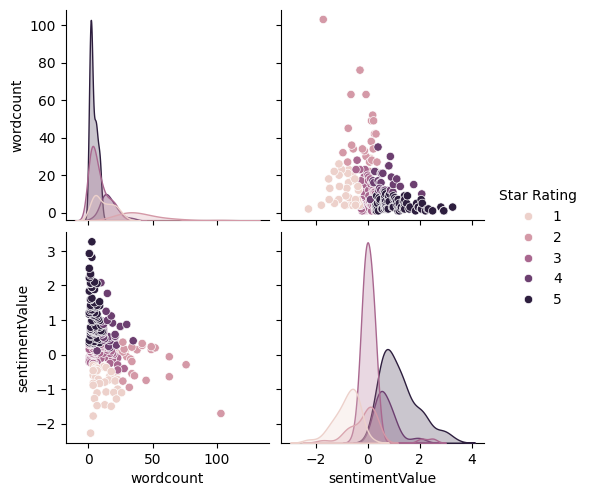

In [9]:
sns.pairplot(df, hue='Star Rating');

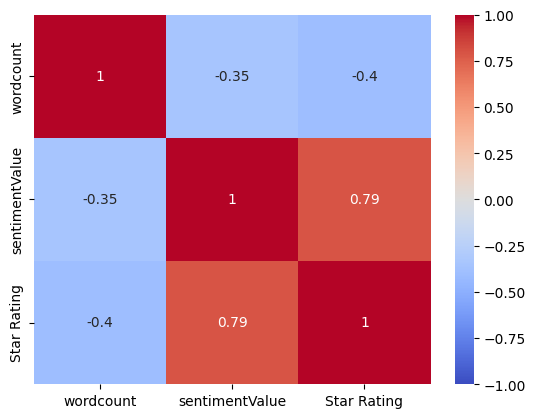

In [10]:
sns.heatmap(df.corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm");

## Preparamos el dataset
Divide en train/test y escala las features en el rango [0, 1].

In [11]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [12]:
from sklearn.model_selection import train_test_split

seed = 45
size = 0.2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size, random_state=seed)

In [75]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()
scoring = 'accuracy'

pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model', model)
])

lst_r1 = 2
lst_r2 = 5

grid = {
    'model__n_neighbors': list(range(lst_r1, lst_r2)),
    'model__weights': ['uniform', 'distance']
}

## Creamos el Modelo
Entrena con un KNN y evalúa el error en train y en test

In [76]:
from sklearn.model_selection import GridSearchCV

cv = 5

grid_search = GridSearchCV(pipe, grid, cv=cv, scoring=scoring)
grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print(f"Mejor Accuracy en CV (Train): {grid_search.best_score_:.4f}")

Mejores parámetros: {'model__n_neighbors': 3, 'model__weights': 'uniform'}
Mejor Accuracy en CV (Train): 0.8927


In [79]:
best_model = grid_search.best_estimator_
best_model.score(X_test, y_test)

0.8269230769230769

## Evalúa tu modelo

In [78]:
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test)
print("\nReporte en Test Set:")
print(classification_report(y_test, y_pred))

# Accuracy (0.83): El 83% de las predicciones totales fueron correctas. Es un buen número general, pero puede ser engañoso si las clases están desbalanceadas.
# Macro Avg (0.82 F1): Trata a todas las clases por igual, sin importar cuántos datos tengan. Al ser cercano al Accuracy, indica que el modelo no está sesgado excesivamente hacia la clase mayoritaria, aunque la Clase 3 tira del promedio hacia abajo.
# Weighted Avg (0.82 F1): Pondera según el número de muestras. Al ser casi idéntico al Macro Avg, confirma que el rendimiento es bastante consistente entre clases, salvo las excepciones mencionadas.


Reporte en Test Set:
              precision    recall  f1-score   support

           1       1.00      0.67      0.80         9
           2       0.86      0.86      0.86         7
           3       0.69      0.85      0.76        13
           4       1.00      0.62      0.77         8
           5       0.83      1.00      0.91        15

    accuracy                           0.83        52
   macro avg       0.88      0.80      0.82        52
weighted avg       0.85      0.83      0.82        52



## ¿Cómo obtener el mejor valor de k? Crea y evalúa nuevos modelos
¿Qué valor de k maximiza el accuracy? Representa todas las iteraciones en un scatterplot -> k vs accuracy

El valor de K que maximiza la Accuracy (en CV) es: 3
Pesos usados: uniform
Accuracy máxima obtenida: 0.8927


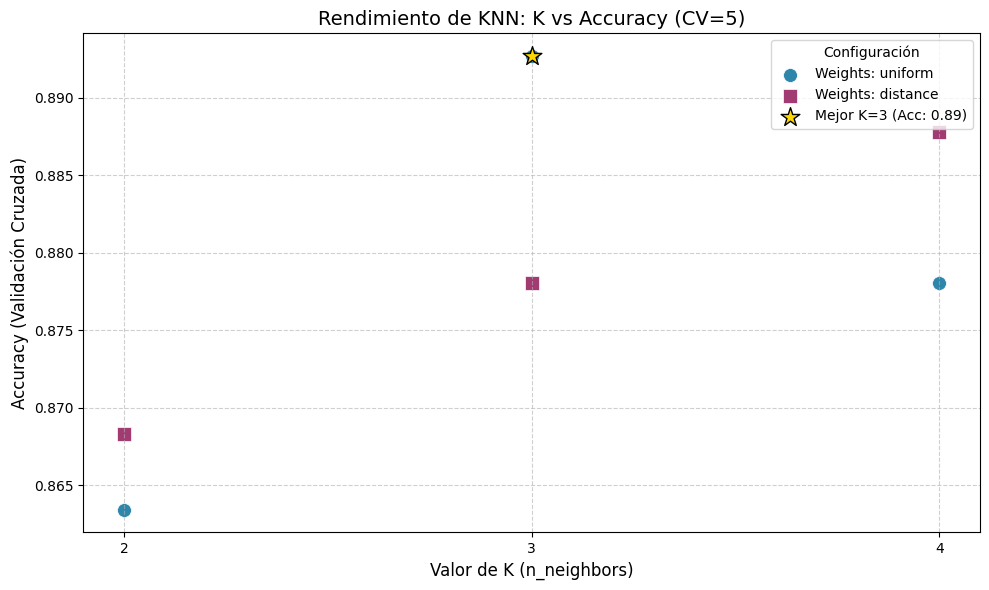

In [81]:

# 1. Extraer los resultados del GridSearch
results = grid_search.cv_results_

# Convertimos a DataFrame para manejarlo mejor
df_results = pd.DataFrame(results)

# Filtramos solo las columnas que nos interesan: los parámetros y el score mean test
# Nota: 'mean_test_score' es la accuracy media de la validación cruzada interna (cv=5)
df_plot = df_results[['param_model__n_neighbors', 'param_model__weights', 'mean_test_score']].copy()

# Renombramos para claridad
df_plot.rename(columns={
    'param_model__n_neighbors': 'k_value',
    'param_model__weights': 'weights',
    'mean_test_score': 'accuracy_cv'
}, inplace=True)

# 2. Encontrar el K que maximiza la accuracy
best_row = df_plot.loc[df_plot['accuracy_cv'].idxmax()]
best_k = int(best_row['k_value'])
best_acc = best_row['accuracy_cv']
best_weights = best_row['weights']

print(f"El valor de K que maximiza la Accuracy (en CV) es: {best_k}")
print(f"Pesos usados: {best_weights}")
print(f"Accuracy máxima obtenida: {best_acc:.4f}")

# 3. Crear el Scatterplot
plt.figure(figsize=(10, 6))

# Separamos por tipo de peso para usar colores diferentes (blue-purple o green-red como prefieres)
# Usaremos 'uniform' y 'distance'
colors = {'uniform': '#2E86AB', 'distance': '#A23B72'} # Azul y Púrpura/Rojo suave
markers = {'uniform': 'o', 'distance': 's'} # Círculo y Cuadrado

for weight_type in df_plot['weights'].unique():
    subset = df_plot[df_plot['weights'] == weight_type]
    plt.scatter(subset['k_value'], subset['accuracy_cv'], 
                label=f'Weights: {weight_type}', 
                color=colors[weight_type],
                marker=markers[weight_type],
                s=100, # Tamaño del punto
                edgecolors='white',
                linewidth=0.5)

# Resaltar el mejor punto
plt.scatter(best_k, best_acc, 
            color='gold', 
            edgecolors='black', 
            zorder=5, 
            s=200, 
            marker='*', 
            label=f'Mejor K={best_k} (Acc: {best_acc:.2f})')

# Títulos y etiquetas
plt.title(f'Rendimiento de KNN: K vs Accuracy (CV={cv})', fontsize=14)
plt.xlabel('Valor de K (n_neighbors)', fontsize=12)
plt.ylabel('Accuracy (Validación Cruzada)', fontsize=12)
plt.xticks(range(lst_r1, lst_r2)) # Asegurar que se vean todos los K probados
plt.legend(title="Configuración")
plt.grid(True, linestyle='--', alpha=0.6)

# Estética limpia
plt.tight_layout()
plt.show()

## Predice con nuevos datos.
Ejemplo: supongamos que nos llega una review de 5 palabras y sentimiento 1

In [82]:
review = [[5, 1]]

best_model.predict(review)

c:\Users\detla\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([5])

In [86]:
nuevos_datos = {
    'wordcount': [5], 
    'sentimentValue': [1]
}

df_nuevo = pd.DataFrame(nuevos_datos)

prediccion = best_model.predict(df_nuevo)
print(f"Estrellas predichas: {prediccion[0]}")

Estrellas predichas: 5
